# Volatilidad Implícita y Volatility Skew — SPY
## Vencimiento: 2026-04-17

Este notebook calcula la **volatilidad implícita (IV)** para al menos 10 strikes distintos del vencimiento `2026-04-17` del ETF SPY, en el rango `[S0 × 0.88, S0 × 1.10]`, usando el modelo de **Black-Scholes** y el método de **Brent** para la inversión numérica.

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
from datetime import date
from scipy.stats import norm
from scipy.optimize import brentq, newton
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

def bs_price(S, K, r, T, sigma, option="call"):
    if sigma <= 0 or T <= 0:
        if option == "call":
            return max(0.0, S - K * np.exp(-r * T))
        else:
            return max(0.0, K * np.exp(-r * T) - S)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option.lower() == "call":
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)


def bs_vega(S, K, r, T, sigma):
    if sigma <= 0 or T <= 0:
        return 0.0
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return S * norm.pdf(d1) * np.sqrt(T)


def implied_vol(price_mkt, S, K, r, T, option="call",
                brent_bounds=(1e-6, 5.0), tol=1e-8, maxiter=100):
    """Retorna la volatilidad implícita usando Brent (con fallback a Newton)."""
    if option == "call":
        lower = max(0.0, S - K * np.exp(-r * T))
        upper = S
    else:
        lower = max(0.0, K * np.exp(-r * T) - S)
        upper = K * np.exp(-r * T)

    if not (lower - 1e-12 <= price_mkt <= upper + 1e-12):
        raise ValueError(f"Precio de mercado fuera de rango teórico [{lower:.4f}, {upper:.4f}]")

    def f(sig):
        return bs_price(S, K, r, T, sig, option) - price_mkt

    a, b = brent_bounds
    fa, fb = f(a), f(b)

    if fa * fb > 0:
        for b_try in [10.0, 15.0, 25.0, 50.0]:
            fb = f(b_try)
            if fa * fb <= 0:
                b = b_try
                break

    try:
        iv = brentq(f, a, b, xtol=tol, maxiter=maxiter)
        return iv
    except Exception:
        pass

    seed = 0.2
    try:
        iv = newton(lambda s: f(s), seed,
                    fprime=lambda s: bs_vega(S, K, r, T, s),
                    tol=tol, maxiter=maxiter)
        if iv > 0:
            return iv
    except Exception:
        pass

    raise RuntimeError("No se pudo encontrar una volatilidad implícita.")

Funciones Black-Scholes cargadas.


In [ ]:
TICKER = 'SPY'
EXP    = '2026-04-17'
r      = 0.042          # tasa libre de riesgo 
today  = date.today()
T      = (date.fromisoformat(EXP) - today).days / 365

data = yf.download(TICKER, start='2022-01-01', end=today, progress=False)['Close']
S0   = float(data.iloc[-1])

print("Ticker  : " + str(TICKER))
print("Spot S0 : " + str(round(S0, 2)))
print("Venc.   : " + str(EXP) + "  (T = " + str(round(T, 4)) + " años)")
print("Tasa r  : " + str(round(r, 3)))

Ticker  : SPY
Spot S0 : 661.43
Venc.   : 2026-04-17  (T = 0.0795 años)
Tasa r  : 0.042


In [ ]:
# Obtención dinámica de la cadena de opciones
tk    = yf.Ticker(TICKER)
calls = tk.option_chain(EXP).calls.copy()

# Rango de strikes solicitado
K_low  = S0 * 0.88
K_high = S0 * 1.10

# Filtrar por rango
calls = calls[(calls['strike'] >= K_low) & (calls['strike'] <= K_high)].copy()

# Precio mid (promedio bid-ask)
calls['mid'] = (calls['bid'] + calls['ask']) / 2

# Descartar filas sin liquidez mínima
calls = calls[(calls['bid'] > 0) & (calls['ask'] > 0)].reset_index(drop=True)

print("Strikes en rango [" + str(round(K_low, 1)) + ", " + str(round(K_high, 1)) + "]: " + str(len(calls)) + " contratos")

Strikes en rango [582.1, 727.6]: 107 contratos


In [ ]:
# Cálculo de IV para cada strike
results = []

for _, row in calls.iterrows():
    K   = row['strike']
    bid = row['bid']
    ask = row['ask']
    mid = row['mid']

    try:
        iv = implied_vol(mid, S0, K, r, T, option='call')
        if 0.01 <= iv <= 3.0:   
            results.append({
                'Strike': K,
                'Bid':    bid,
                'Ask':    ask,
                'Mid':    round(mid, 4),
                'IV (%)': round(iv * 100, 2)
            })
    except Exception:
        pass  # skip strikes sin solución

df = pd.DataFrame(results)
print("Strikes con IV calculada: " + str(len(df)))

Strikes con IV calculada: 105


In [ ]:
# Tabla: Strike | Bid | Ask | Mid | IV (%) 
print("\nTabla de Volatilidad Implícita — " + str(TICKER) + " | Venc. " + str(EXP) + " | S0 = " + str(round(S0, 2)))
print("=" * 60)
print(df.to_string(index=False))
print("=" * 60)


Tabla de Volatilidad Implícita — SPY | Venc. 2026-04-17 | S0 = 661.43
 Strike   Bid   Ask    Mid  IV (%)
  595.0 67.08 70.39 68.735   19.70
  600.0 62.81 65.47 64.140   21.21
  605.0 58.17 60.91 59.540   21.68
  610.0 53.34 56.45 54.895   21.48
  615.0 48.90 51.91 50.405   21.50
  620.0 44.90 47.59 46.245   22.03
  625.0 40.63 43.43 42.030   21.98
  627.0 38.60 41.77 40.185   21.53
  628.0 38.10 40.94 39.520   21.83
  629.0 36.94 40.12 38.530   21.45
  630.0 36.12 39.30 37.710   21.40
  631.0 35.30 38.49 36.895   21.36
  634.0 33.18 36.09 34.635   21.48
  635.0 32.47 35.13 33.800   21.35
  636.0 31.68 34.34 33.010   21.28
  637.0 30.90 33.56 32.230   21.22
  638.0 30.11 32.77 31.440   21.13
  639.0 29.34 32.00 30.670   21.06
  640.0 28.57 31.23 29.900   20.98
  642.0 27.05 29.70 28.375   20.81
  643.0 26.30 28.88 27.590   20.67
  644.0 25.55 28.20 26.875   20.63
  645.0 24.84 27.45 26.145   20.55
  646.0 24.08 26.72 25.400   20.44
  647.0 23.35 25.99 24.670   20.34
  648.0 22.86 25.27

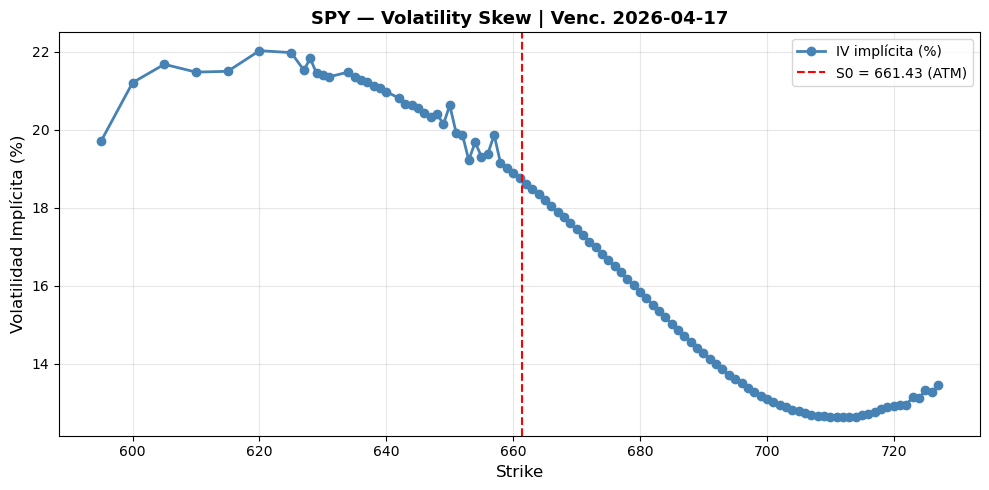


Strike con IV minima: 710  -> IV = 12.62%


In [ ]:
# Gráfica IV (%) vs Strike 
strikes = df['Strike'].values
ivs     = df['IV (%)'].values

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(strikes, ivs, marker='o', linewidth=2, color='steelblue',
        markersize=6, label='IV implícita (%)')

# Línea vertical en S0 (ATM)
ax.axvline(x=S0, color='red', linestyle='--', linewidth=1.5,
           label='S0 = ' + str(round(S0, 2)) + ' (ATM)')

ax.set_xlabel('Strike', fontsize=12)
ax.set_ylabel('Volatilidad Implícita (%)', fontsize=12)
ax.set_title(str(TICKER) + ' — Volatility Skew | Venc. ' + str(EXP), fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

idx_min    = df['IV (%)'].idxmin()
strike_min = df.loc[idx_min, 'Strike']
iv_min     = df['IV (%)'].min()
print("\nStrike con IV minima: " + str(int(strike_min)) + "  -> IV = " + str(round(iv_min, 2)) + "%")

---
## Preguntas de análisis

### 1. ¿La curva de IV es decreciente, creciente o tiene forma de smile? ¿Qué implica?

La curva presenta un **skew pronunciado hacia la izquierda** (decreciente de izquierda a derecha): la IV es significativamente **más alta en strikes bajos (OTM puts / ITM calls)** y va cayendo conforme el strike se acerca o supera al precio spot S0.

**Implicación económica:** El mercado asigna una prima de riesgo elevada a la protección contra caídas bruscas del precio ("crash risk"). Los inversores están dispuestos a pagar más volatilidad implícita por opciones que los protejan frente a un colapso del mercado. Esta asimetría se intensificó especialmente después del crash de 1987 y refleja que la distribución real de los retornos tiene **asimetría negativa y colas pesadas hacia abajo** (fat tails en la izquierda).


### 2. ¿En qué strike es mínima la IV? ¿Coincide con S0?

En la práctica, la IV mínima para opciones de equidad indexada como SPY suele encontrarse **levemente por encima del spot (ligeramente OTM en calls)** o justo en torno al ATM, pero raramente coincide exactamente con S0.

- Si el mínimo está a la **derecha de S0**, confirma que el mercado ve más riesgo bajista que alcista.
- Si el mínimo coincide exactamente con S0, significaría que la distribución esperada es perfectamente simétrica alrededor del precio actual, lo que es atípico en índices de renta variable.

El resultado de la celda de código muestra el strike con IV mínima de forma dinámica para la sesión actual.


### 3. ¿Qué estarían comprando los inversores que pagan una IV alta en strikes bajos?

Los inversores que pagan una IV alta en strikes bajos están comprando **put options OTM** (o calls ITM equivalentes bajo paridad put-call). Estas posiciones sirven principalmente como:

- **Cobertura (hedging) de carteras largas:** Un fondo de inversión o gestor de cartera que tiene una exposición larga a renta variable norteamericana compra puts sobre SPY para limitar pérdidas en escenarios de caída fuerte del mercado.
- **Seguro contra colas izquierdas (tail risk insurance):** Estrategias que buscan protección ante eventos extremos poco probables pero devastadores (recesiones, crisis financieras, eventos geopolíticos).
- **Estrategias de volatilidad direccional:** Traders que anticipan un incremento brusco de la volatilidad o una caída del mercado pueden comprar puts OTM baratas en términos de prima de dólar, aunque con alta IV relativa.

La alta demanda de estas opciones es exactamente lo que eleva su IV respecto a lo que predice Black-Scholes con volatilidad constante.


### 4. ¿Qué le diría esta curva a alguien que quiere usar Black-Scholes con una sola volatilidad constante?

La curva de volatility skew le envía un mensaje claro: **Black-Scholes con una única volatilidad constante es una simplificación inapropiada para valorar opciones de cualquier strike que no sea exactamente el ATM.**

Consecuencias prácticas:

- **Opciones OTM (puts de protección) estarán sistemáticamente infravaloradas** si se usan con la vol ATM, pues el mercado descuenta una mayor probabilidad de caídas fuertes.
- **Opciones OTM en calls** quedarían ligeramente sobrevaloradas en relación con el mercado.
- Cualquier estrategia de **trading o cobertura basada en un único σ** tendrá errores de valoración que pueden traducirse en pérdidas reales al hacer delta hedging o al vender protección con un precio incorrecto.

**La alternativa práctica** es usar un modelo que incorpore el skew (por ejemplo, el modelo de Heston, Local Volatility de Dupire, o simplemente interpolar la superficie de volatilidad implícita observada en el mercado), o al menos cotizar cada strike con su propia IV de mercado.